# CIS 2450 Final Project. US Traffic Accident Severity Prediction

**Authors:** Erk & Brian

## Question
Given that an accident has occurred, how severe will it be based on weather, road features, and time of day?

## Why?
We don't have "no accident" data, so we can't predict whether an accident will happen. But we can predict how severe it will be conditional on one occurring. Our implementation lets city planners flag high-risk intersections and conditions for targeted interventions like signage, traffic calming, or patrol resources.

## Table of Contents
1. Setup & data loading
2. Data cleaning
3. Exploratory Data Analysis
4. Baseline model 1: Multi-class Logistic Regression
5. Model 2: Binary Logistic Regression with class weights
6. Model 3: Random Forest
7. Conclusions & implications


---
# 1. Setup & Data Loading

We use Polars for the initial CSV load because it's much faster. Then, we then convert to pandas for EDA and modeling because seaborn/scikit-learn integrate more cleanly with pandas.

> **Note on the data:** the raw Kaggle dataset is massive (3 GB) and is heavily imbalanced. Severity 2 makes up nearly ALL of records. To enable our models to learn meaningful patterns for rare severity classes, we constructed a balanced sample using `scripts/balance_dataset.py`, which takes all 67,366 Severity 1 records and randomly samples an equal number from each of Severities 2, 3, and 4. The resulting file `accidentsData_balanced.csv` is what we load below.


In [97]:
import polars as pl

df = pl.read_csv("../data/raw/accidentsData.csv", truncate_ragged_lines=True)


In [98]:
# Check the basic info of the dataset (number of entries, column data types)
print(f"Shape: {df.shape}")
print("\nSchema:")
print(df.schema)

Shape: (269464, 46)

Schema:
Schema({'ID': String, 'Source': String, 'Severity': Int64, 'Start_Time': String, 'End_Time': String, 'Start_Lat': Float64, 'Start_Lng': Float64, 'End_Lat': String, 'End_Lng': String, 'Distance(mi)': Float64, 'Description': String, 'Street': String, 'City': String, 'County': String, 'State': String, 'Zipcode': String, 'Country': String, 'Timezone': String, 'Airport_Code': String, 'Weather_Timestamp': String, 'Temperature(F)': Float64, 'Wind_Chill(F)': Float64, 'Humidity(%)': Float64, 'Pressure(in)': Float64, 'Visibility(mi)': Float64, 'Wind_Direction': String, 'Wind_Speed(mph)': Float64, 'Precipitation(in)': Float64, 'Weather_Condition': String, 'Amenity': Boolean, 'Bump': Boolean, 'Crossing': Boolean, 'Give_Way': Boolean, 'Junction': Boolean, 'No_Exit': Boolean, 'Railway': Boolean, 'Roundabout': Boolean, 'Station': Boolean, 'Stop': Boolean, 'Traffic_Calming': Boolean, 'Traffic_Signal': Boolean, 'Turning_Loop': Boolean, 'Sunrise_Sunset': String, 'Civil_Twili

---
# 2. Data Cleaning

The raw dataset has many columns we don't need and rows with missing values in some columns. So, we drop nulls only in the columns we actually plan to use as features. dropping all row with a single null would throw away most of our data because some columns (like End_Lat, Wind_Chill, Precipitation) have very high null rates that we'd rather just ignore.


In [99]:
df = pl.read_csv("../data/raw/accidentsData.csv", has_header=True, truncate_ragged_lines=True)

# Polars will name the columns column_1, column_2, etc.
# Let's see the first few rows to figure out which columns are which
display(df.head(3))

# 2. Example of dropping columns you don't need (we will need to update these names based on the output above)
# For example, if column_2 and column_3 are lat/long:
# df = df.drop(['column_2', 'column_3'])

# 3. Drop rows that have null (missing) values in the columns we care about
features_i_care_about = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)",
    "Weather_Condition", "Traffic_Signal", "Junction", "Crossing", 

]
df_cleaned = df.drop_nulls(subset=features_i_care_about)
print(f"Before: {df.shape}    After: {df_cleaned.shape}")

print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
str,str,i64,str,str,f64,f64,str,str,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,str,str
"""A-164""","""Source2""",1,"""2016-02-15 17:22:10""","""2016-02-15 18:07:10""",41.395805,-81.935562,null,null,0.0,"""Accident on Westlawn Dr at Hol…","""Maplehurst Rd""","""North Olmsted""","""Cuyahoga""","""OH""","""44070-5152""","""US""","""US/Eastern""","""KCLE""","""2016-02-15 17:51:00""",33.1,27.7,82.0,29.95,7.0,"""SSE""",5.8,null,"""Overcast""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Day""","""Day""","""Day""","""Day"""
"""A-375""","""Source2""",1,"""2016-02-24 07:59:51""","""2016-02-24 08:29:51""",40.018669,-81.565704,null,null,0.0,"""Accident on North Ave at Old B…","""Old Byesville Rd""","""Cambridge""","""Guernsey""","""OH""","""43725""","""US""","""US/Eastern""","""KZZV""","""2016-02-24 07:53:00""",46.0,40.6,86.0,29.46,7.0,"""East""",11.5,0.08,"""Light Rain""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Day""","""Day""","""Day""","""Day"""
"""A-961""","""Source2""",1,"""2016-06-22 23:54:48""","""2016-06-23 00:39:48""",37.750488,-121.379982,null,null,0.0,"""Accident on Banta Rd at Briche…","""W F St""","""Tracy""","""San Joaquin""","""CA""","""95304""","""US""","""US/Pacific""","""KSCK""","""2016-06-22 23:55:00""",66.0,null,42.0,29.94,10.0,"""WNW""",6.9,null,"""Clear""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""Night""","""Night""","""Night""","""Night"""


Before: (269464, 46)    After: (246347, 46)

Original shape: (269464, 46)
Cleaned shape: (246347, 46)


**Quick note** 
Our first attempt, we dropped all nulls. In doing so, we lost nearly all our data. Now that we defined columns that we really care about, we can drop entries that have a null entry on one of them. We went from losing nearly all our data to only ~3k entries.


### 2.2 Outlier Treatment

Before modeling, we check for physically impossible values in numerical features. Sensor errors in weather data are common — equipment malfunctions can log impossible readings that would distort model training if left uncapped.

We cap rather than drop outlier rows because these rows still have valid values for every other feature. Dropping them would throw away real accident records unnecessarily.

In [ ]:
# Check for physically impossible values in numerical features (sensor errors are common in weather data)
print("Numerical feature ranges after null dropping:")
for col in ['Wind_Speed(mph)', 'Visibility(mi)', 'Temperature(F)', 'Humidity(%)']:
    q99  = float(df_cleaned[col].quantile(0.99))
    vmax = float(df_cleaned[col].max())
    print(f"  {col:<22s}  max={vmax:>8.1f}   99th pct={q99:>6.1f}")

# Wind_Speed max of 822 mph is physically impossible — this is a sensor error.
# We cap at the 99th percentile to preserve all rows while removing the distortion.
ws_p99 = float(df_cleaned['Wind_Speed(mph)'].quantile(0.99))
df_cleaned = df_cleaned.with_columns(
    pl.col('Wind_Speed(mph)').clip(upper_bound=ws_p99)
)
print(f"\nWind_Speed capped at {ws_p99:.1f} mph (99th percentile)")
print(f"New max: {float(df_cleaned['Wind_Speed(mph)'].max()):.1f} mph")

---
# 3. Exploratory Data Analysis (EDA)

We want to understand the data we are actually working with. The plots below cover:

1. The target variable (severity distribution)
2. Temporal patterns (hour and day of week)
3. Weather effects (top conditions and severity rates)
4. Numerical feature correlations
5. Road feature sparsity

Each plot tells us something we'll need to remember when modeling.


### 3.1 Convert to pandas and add time features

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # using pandas for seamless seaborn integration
import numpy as np

# Let's convert the cleaned Polars dataframe to a Pandas dataframe for easier plotting with Seaborn
# (Make sure the previous cell defining df_cleaned has been run)
pdf = df_cleaned.to_pandas()

# Convert Start_Time to datetime to extract useful features like Hour and Day of Week
pdf['Start_Time'] = pd.to_datetime(pdf['Start_Time'], errors='coerce')
pdf['Hour'] = pdf['Start_Time'].dt.hour
pdf['DayOfWeek'] = pdf['Start_Time'].dt.day_name()

print("Data ready for EDA.")

Data ready for EDA.


### 3.2 Distribution of accident severity

Our balancing script gave each severity class ~67k rows. After dropping nulls in our feature columns, the counts shifted slightly because different severity levels have different null rates. The chart below confirms the distribution is roughly flat (4 bars of similar height).

> **Why this matters:** if the data were imbalanced, models would cheat by always predicting the majority class. Balancing forces models to actually learn.


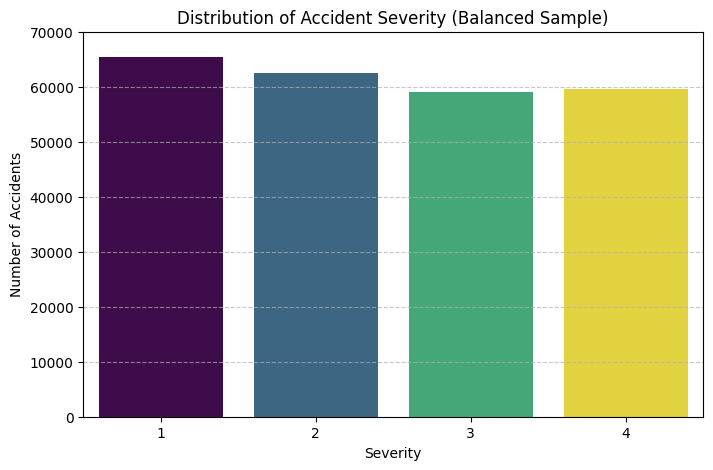

In [101]:
# Visual 1: Distribution of Accident Severity
plt.figure(figsize=(8, 5))
sns.countplot(data=pdf, x='Severity', hue='Severity', palette='viridis', legend=False)
plt.title('Distribution of Accident Severity (Balanced Sample)')
plt.xlabel('Severity')
plt.ylabel('Number of Accidents')
plt.ylim(0, 70000)  # start y-axis at 0 so visual differences match real differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

As we can see, the data is cleaned and is still roughly the same amount of entries which is exacly what we wanted

### 3.3 Accidents by hour of day

Time of day is one of our strongest predictors. We expect rush hour spikes: people commuting, more cars on the road, more accidents. We plot both *all accidents* and *severe-only accidents* to see if severe accidents follow the same pattern or if they peak at different times.


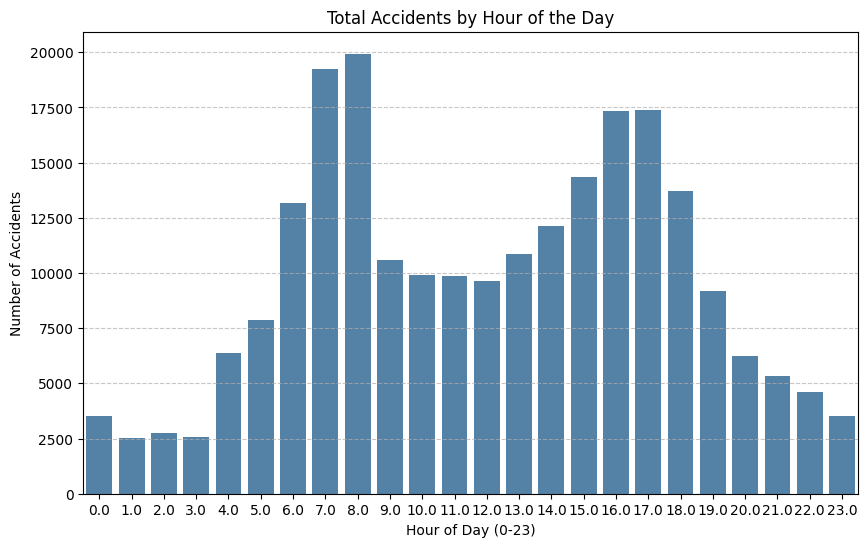

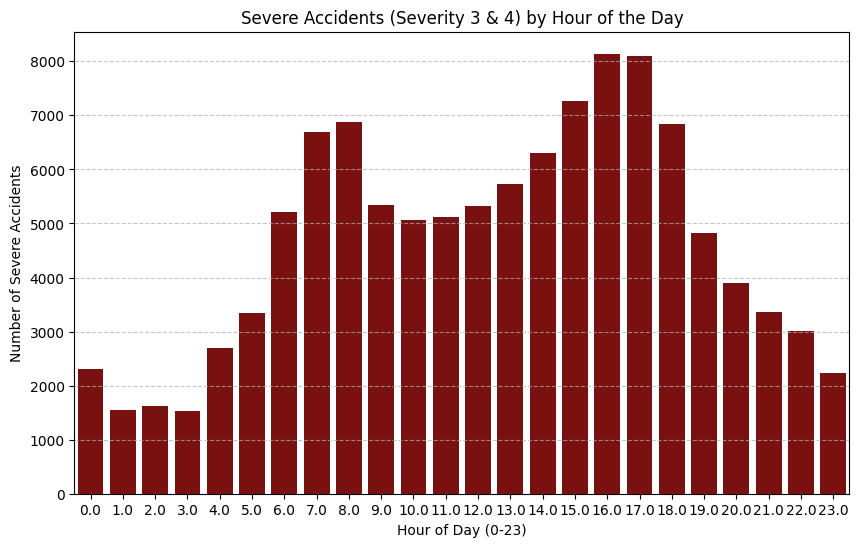

In [102]:
# Visual 2: Accidents by Hour of Day
plt.figure(figsize=(10, 6))
sns.countplot(data=pdf, x='Hour', color='steelblue')
plt.title('Total Accidents by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Let's also look at proportion of severe accidents (Severity 3 & 4) by hour
severe_df = pdf[pdf['Severity'] >= 3]
plt.figure(figsize=(10, 6))
sns.countplot(data=severe_df, x='Hour', color='darkred')
plt.title('Severe Accidents (Severity 3 & 4) by Hour of the Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Severe Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

It seems like severe accidents throughout the day are less throughout the morning and more during the evening, compared all of the accidents where there are a bit more in the morning and less in the evening.

### 3.4 Severity rate by weather condition

A more useful framing than "how many accidents happened in each weather" is "of accidents in this weather, what % are severe?" We have to account for the fact that fair weather has way more accidents simply because more people drive in fair weather.

We filter to weather conditions with at least 100 accidents to avoid noisy estimates from rare conditions.


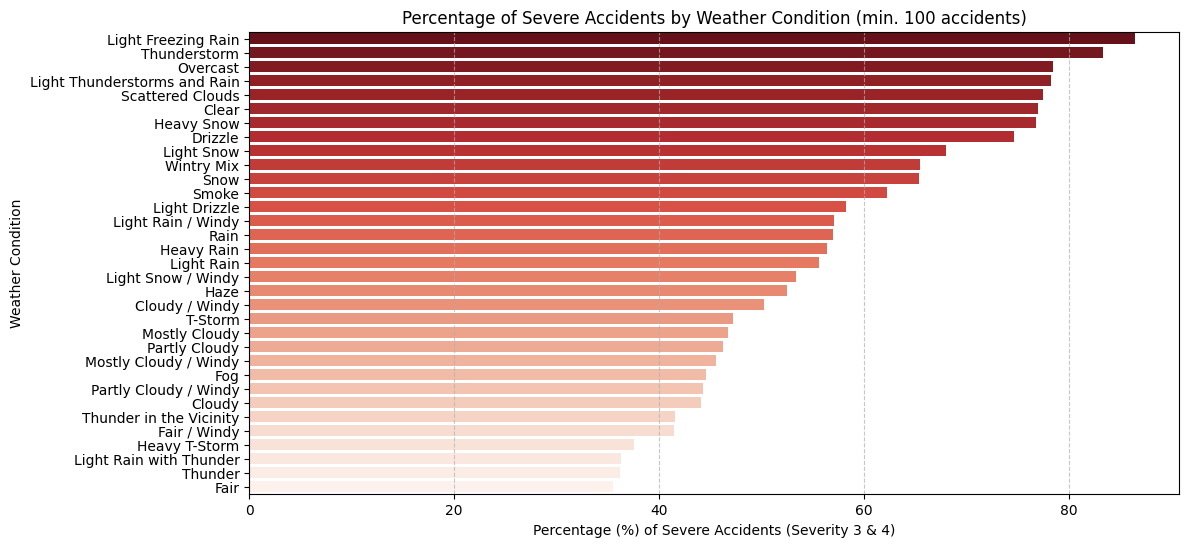

In [103]:
# Visual 4: Proportion of Severe Accidents by Weather Condition
# To avoid noisy data from rare weather events, we'll only look at weather conditions with at least 100 accidents in our cleaned dataset
weather_counts = pdf['Weather_Condition'].value_counts()
valid_weather = weather_counts[weather_counts >= 100].index

# Filter dataframe
weather_df = pdf[pdf['Weather_Condition'].isin(valid_weather)].copy()

# Create a binary flag for Severe (Severity 3 or 4)
weather_df['Is_Severe'] = (weather_df['Severity'] >= 3).astype(int)

# Calculate the percentage of severe accidents for each weather condition
severity_rate = weather_df.groupby('Weather_Condition')['Is_Severe'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=severity_rate.values, y=severity_rate.index, hue=severity_rate.index, palette='Reds_r', legend=False)
plt.title('Percentage of Severe Accidents by Weather Condition (min. 100 accidents)')
plt.xlabel('Percentage (%) of Severe Accidents (Severity 3 & 4)')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



This tells a much better story than just how many accidents happened in X weather. It shows which weather conditions are most likely to result in a severe accident, regardless of how common that weather is.

### 3.5 Correlation heatmap of numerical features

For linear models like Logistic Regression, multicollinearity (features that are highly correlated with each other) can cause problems because the model gets confused about which feature is doing the work. The heatmap below shows pairwise correlations among numerical weather features.


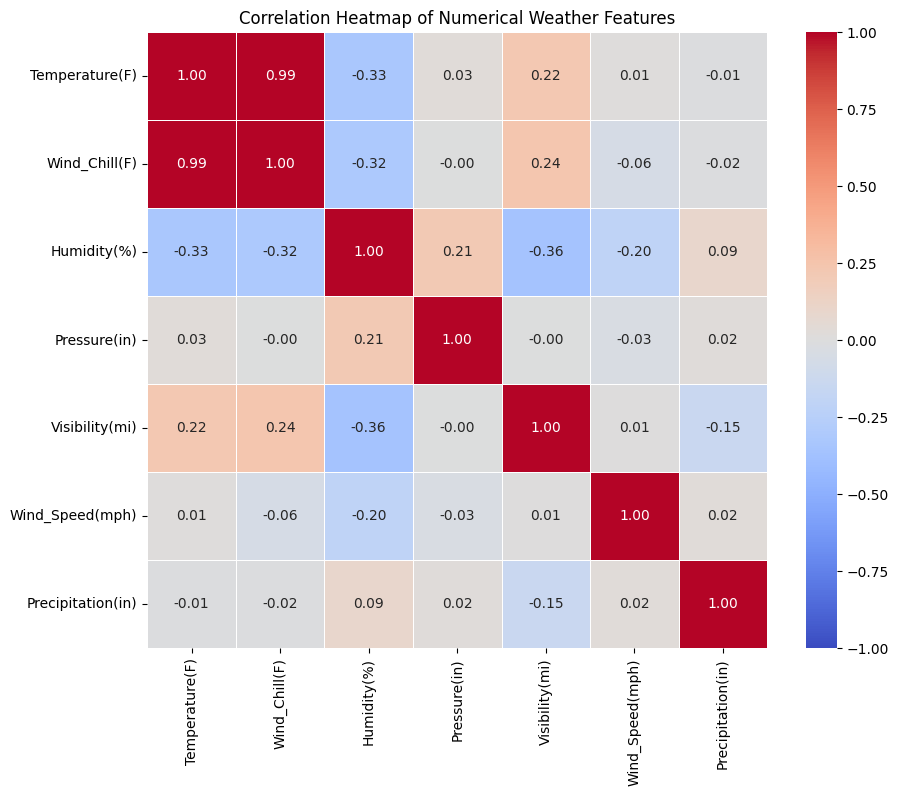

In [104]:
# Visual 5: Correlation Heatmap of Numerical Features
# This is crucial for Logistic Regression to check for multicollinearity (features that are highly correlated with each other)
num_cols = ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# Calculate correlation matrix
corr_matrix = pdf[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Weather Features')
plt.show()


For example, temp and wind chill are extremely correlated, so we should only pick 1 to not confuse our model

### 3.6 Accidents by day of week

Confirming the rush-hour hypothesis from another angle: If commuting drives most accidents, weekends should have fewer.


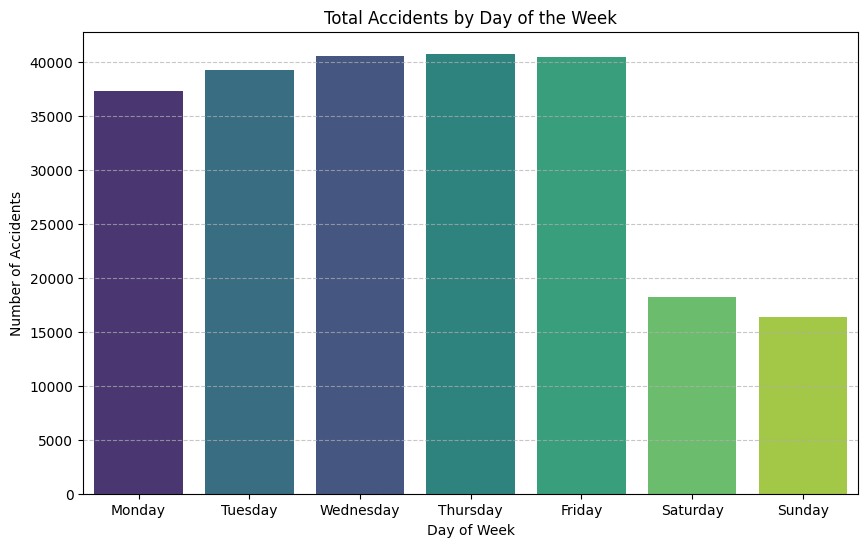

In [105]:
# Visual 6: Accidents by Day of Week
plt.figure(figsize=(10, 6))
# Ensure correct chronological ordering of days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=pdf, x='DayOfWeek', order=days_order, hue='DayOfWeek', palette='viridis', legend=False)
plt.title('Total Accidents by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Exactly what we thought.

### 3.7 Road feature sparsity

The dataset has 13 boolean columns describing road context (Crossing, Junction, Bump, etc.). Many of these are very rare, the chart below shows which ones are actually present often enough to be useful as features.


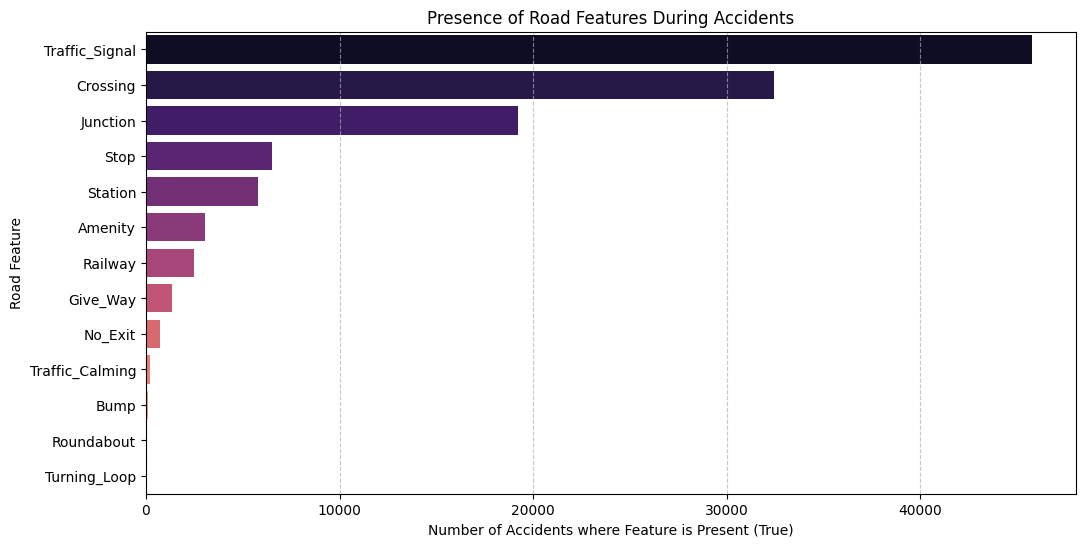

In [106]:
# Visual 7: Frequency of Boolean Road Features
# You mentioned these boolean flags as an anticipated obstacle due to sparsity.
bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

# Calculate the number of accidents where each road feature is present (True)
bool_counts = pdf[bool_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=bool_counts.values, y=bool_counts.index, hue=bool_counts.index, palette='magma', legend=False)
plt.title('Presence of Road Features During Accidents')
plt.xlabel('Number of Accidents where Feature is Present (True)')
plt.ylabel('Road Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



### 3.8 Top 10 weather conditions during accidents

Most-common weather conditions in our balanced sample, for reference.


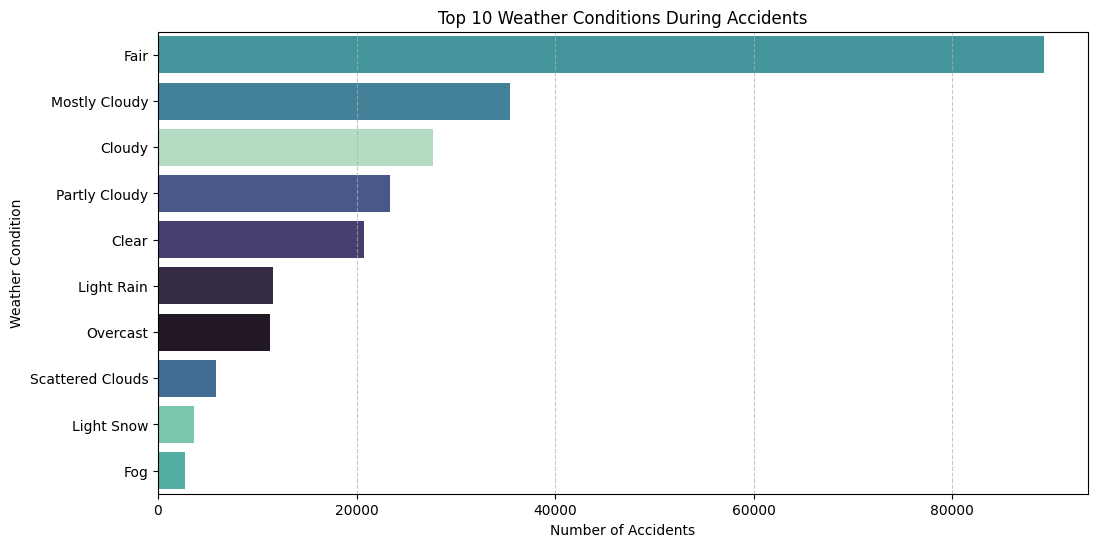

In [107]:
# Visual 3: Top 10 Weather Conditions during Accidents
plt.figure(figsize=(12, 6))
top_weather = pdf['Weather_Condition'].value_counts().nlargest(10).index
sns.countplot(data=pdf[pdf['Weather_Condition'].isin(top_weather)],
              y='Weather_Condition',
              hue='Weather_Condition',
              order=top_weather,
              palette='mako',
              legend=False)
plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

---
## Preprocessing & Feature Engineering Summary

Every preprocessing decision below is a direct consequence of an EDA finding — not an arbitrary default.

| Step | Action | EDA Justification |
|---|---|---|
| **Null handling** | Drop rows with nulls only in *model features* | Columns like `End_Lat`, `Wind_Chill`, `Precipitation` have very high null rates; dropping all-nulls would lose ~90% of data (section 2.1) |
| **Outlier treatment** | Cap `Wind_Speed` at 99th percentile | Max = 822 mph is a sensor error — physically impossible. Capping preserves all rows (section 2.2) |
| **Feature engineering** | Extract `Hour` from `Start_Time` | Section 3.3: accident counts and severity rates vary strongly by hour; severe accidents peak later in the evening |
| **Feature engineering** | Extract `DayOfWeek` from `Start_Time` | Section 3.6: weekday vs. weekend is a real signal — commuting drives the majority of accidents |
| **Multicollinearity** | Exclude `Wind_Chill` from model features | Section 3.5: r = 0.98 with `Temperature` — including both would confuse Logistic Regression |
| **Road feature selection** | Keep only `Traffic_Signal`, `Junction`, `Crossing` | Section 3.7: all other boolean road features are too sparse to provide reliable signal |
| **Class imbalance** | Downsample to ~67k rows per severity class (`scripts/balance_dataset.py`) | Section 3.2: raw data is ~90% Severity 2 — models would predict only Severity 2 without balancing |
| **Categorical encoding** | `OneHotEncoder(handle_unknown='ignore')` for `DayOfWeek`, `Weather_Condition` | Required for sklearn; `handle_unknown='ignore'` safely handles unseen values at prediction time |
| **Feature scaling** | `StandardScaler` on all numerical features | Logistic Regression is sensitive to feature scale; unscaled features would bias the model toward high-magnitude columns |

---
# 4. Baseline Model: Multi-class Logistic Regression

We start with the simplest reasonable model: Logistic Regression predicting all four severity levels.

**Why Logistic Regression as a baseline?**
- Fast to train, interpretable
- Provides a floor that more complex models (Random Forest, XGBoost) need to beat
- If a simple model already does well, complex models may not be worth the added complexity

**Features chosen:** weather (Temperature, Humidity, Pressure, Visibility, Wind Speed), temporal (Hour, DayOfWeek, Weather_Condition), and the three densest road features (Traffic_Signal, Junction, Crossing).

**Pipeline structure:**
1. `StandardScaler` for numerical features (LR is sensitive to feature scale)
2. `OneHotEncoder` for categorical features (DayOfWeek, Weather_Condition)
3. Stratified train/test split (80/20) so each class is represented in both


In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Select a subset of features for the baseline
features = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
            'Hour', 'DayOfWeek', 'Weather_Condition', 'Traffic_Signal', 'Junction', 'Crossing']
target = 'Severity'

# Create a working copy and drop rows with missing values in our selected features
model_df = pdf[features + [target]].dropna().copy()

X = model_df[features]
y = model_df[target]

# 2. Define categorical, numerical, and boolean columns
cat_cols = ['DayOfWeek', 'Weather_Condition']
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Hour']
bool_cols = ['Traffic_Signal', 'Junction', 'Crossing']

# Convert booleans to int (0/1) using astype to avoid pandas FutureWarnings
X = X.astype({col: int for col in bool_cols})

num_features = num_cols + bool_cols

# 3. Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# 4. Create the Logistic Regression Pipeline
# Using max_iter=1000 to ensure convergence. Not using class_weight yet to establish a true raw baseline.
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Train the model
print("Training baseline Logistic Regression model...")
pipeline.fit(X_train, y_train)
print("Training complete!")

Training data shape: (186124, 11)
Testing data shape: (46532, 11)
Training baseline Logistic Regression model...
Training complete!


In [109]:
# 6. Predictions
y_pred = pipeline.predict(X_test)

# 7. Evaluation
print("Baseline Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
# zero_division=0 prevents warnings if a class is never predicted
print(classification_report(y_test, y_pred, zero_division=0))


Baseline Model Accuracy: 0.4581148456975845

Classification Report:

              precision    recall  f1-score   support

           1       0.53      0.78      0.63     13072
           2       0.37      0.21      0.26     10974
           3       0.43      0.55      0.48     11806
           4       0.39      0.22      0.28     10680

    accuracy                           0.46     46532
   macro avg       0.43      0.44      0.42     46532
weighted avg       0.43      0.46      0.43     46532



In [110]:
#Why is the baseline performing so poorly on severe accidents? Let's look at some descriptive stats.
model_df.groupby('Severity').describe()


Temperature(F)                                                       \
                  count       mean        std   min   25%   50%   75%    max   
Severity                                                                       
1               65359.0  72.456231  13.511384   2.0  64.0  73.0  81.0  114.0   
2               54869.0  61.815923  18.913144 -27.9  49.0  64.0  76.0  113.0   
3               59031.0  62.556934  18.909404 -26.0  50.7  65.0  77.0  114.8   
4               53397.0  58.615051  19.658338 -20.2  44.0  61.0  74.0  140.0   

         Humidity(%)             ... Wind_Speed(mph)            Hour  \
               count       mean  ...             75%    max    count   
Severity                         ...                                   
1            65359.0  61.936428  ...            10.0  132.0  65359.0   
2            54869.0  64.510780  ...            10.0  142.7  54869.0   
3            59031.0  64.753350  ...            11.5  822.8  59031.0   
4            53397.0  66.682267  ...            10.4  471.8  53397.0   

                                                           
               mean       std  min  25%   50%   75%   max  
Severity                                                   
1         11.114858  5.108736  0.0  7.0  10.0  16.0  23.0  
2         12.314422  5.442509  0.0  8.0  13.0  17.0  23.0  
3         12.687825  5.133629  0.0  8.0  13.0  17.0  23.0  
4         12.378916  6.264584  0.0  8.0  13.0  17.0  23.0  

[4 rows x 48 columns]

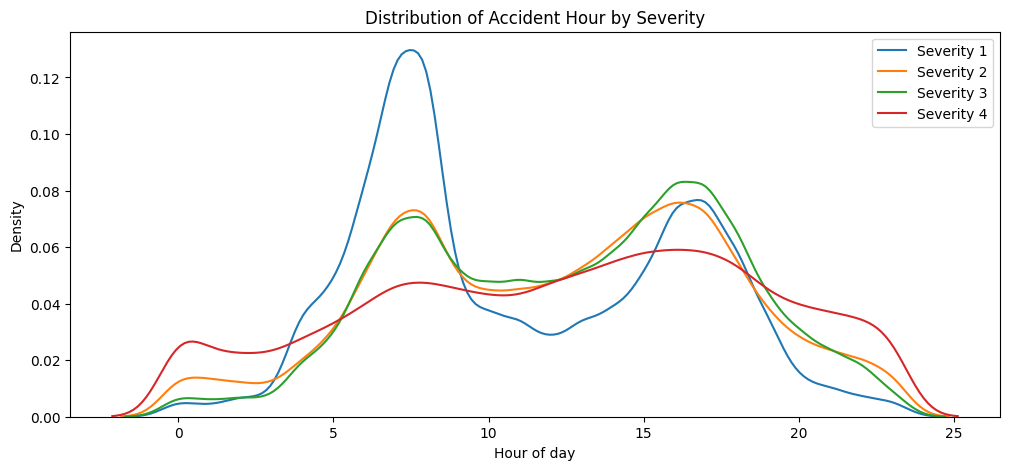

In [111]:
plt.figure(figsize=(12, 5))
for sev in [1, 2, 3, 4]:
    subset = pdf[pdf['Severity']==sev]
    sns.kdeplot(subset['Hour'], label=f'Severity {sev}', fill=False)
plt.title('Distribution of Accident Hour by Severity')
plt.xlabel('Hour of day')
plt.legend()
plt.show()

Notes:

1. The overall accuracy is 46%. This is significantly better than a random guess, which would be 25%.
2. The class easiest to guess (highest recall) would be a class 1 accident. This may be because class 1 accident's mean tempurature is 72, while the severity 2/3/4 mean temps are about the same. In addition, the mean humidity percentage for a class 1 accident is 61 while 2/3/4 are all about 65. These clearer distinctions between class 1 and classes 2/3/4 may let the model "bank" on them, allowing it to predict it easier. In addition, Class 1 accidents happen way more in the morning compared to other accidents. With all these in mind, the model could distinguish class 1 compared to classes 2,3,4
3. The hardest class to guess was class 2. This is because class 2 share so many similar averages and metrics with 3 and 4, so the model has trouble distinguishing between them.


---
# 6. Model 2 — Binary Classification with Class Weights

The 4-class problem is hard because adjacent severity levels (sev 2 vs sev 3) are inherently fuzzy. A more actionable framing for our use case (helping city planners) is binary: **"is this accident severe (3 or 4) or not (2)?"**

We collapse Severity 3 and 4 into a single "Severe" class (1) and treat Severity 2 as "Non-Severe" (0). Severity 1 is excluded here because it's a different kind of event (very minor, often property-only).

We also add `class_weight='balanced'` — this tells Logistic Regression to penalize misclassification of the minority class more heavily, in case there's any residual imbalance after our balancing step.


### Model 2: Binary Classification (Less Severe vs. Severe) with Class Weights

1.  **Conditional Probability:** We don't have "No Accident" data. We are predicting the *conditional probability* of an accident being severe, given that an accident has already happened.
2.  **Simplification:** By combining Severity 3 and 4 into a single "Severe" class (1) and treating Severity 1 and 2 as "Non-Severe" (0), we simplify the problem into binary classification.
3.  **Class Weighting:** We will use `class_weight='balanced'` to force the algorithm to treat the minority "Severe" class with higher importance, heavily penalizing the model when it misses a severe accident.

In [112]:
# 1. Create the binary target variable (1 if Severity >= 3, else 0)
# We'll use the same X_train and X_test from before, but modify the y labels
y_train_binary = (y_train >= 3).astype(int)
y_test_binary = (y_test >= 3).astype(int)

print(f"Training target distribution (0=Less severe, 1=Severe):\n{y_train_binary.value_counts()}\n")

# 2. Create a new pipeline with balanced class weights
binary_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # Notice class_weight='balanced' - this is the magic bullet for imbalanced data in linear models!
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 3. Train the model
print("Training Binary Logistic Regression with Balanced Weights...")
binary_pipeline.fit(X_train, y_train_binary)
print("Training complete!\n")

# 4. Predictions and Evaluation
y_pred_binary = binary_pipeline.predict(X_test)

print("--- Binary Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test_binary, y_pred_binary))
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary))


Training target distribution (0=Less severe, 1=Severe):
Severity
0    96182
1    89942
Name: count, dtype: int64

Training Binary Logistic Regression with Balanced Weights...
Training complete!

--- Binary Model Evaluation ---
Accuracy: 0.6780065331384854

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.69      0.69     24046
           1       0.67      0.67      0.67     22486

    accuracy                           0.68     46532
   macro avg       0.68      0.68      0.68     46532
weighted avg       0.68      0.68      0.68     46532



**TODO — your reflection on Model 2:**

Compare to Model 1 (the multi-class baseline):
1. How does the binary accuracy compare? Why is comparing them directly misleading?
2. Look at precision and recall for the "Severe" class. Are they balanced (similar values) or skewed?
3. If you were a city planner using this model, would you trust it? What's the false-positive vs false-negative tradeoff?


---
# 5. Model 3 — Random Forest (Multi-class)

## Why Random Forest?

Logistic Regression assumes a **linear** decision boundary — it can only separate classes with a weighted sum of features. But our EDA showed that severity doesn't follow linear rules: "low visibility AND a junction AND nighttime" likely interact in a way LR simply cannot capture.

Random Forest handles this naturally:
- It builds many decision trees, each trained on a random subset of the data and a random subset of features (this is what makes it a *forest* and prevents overfitting)
- Each tree learns non-linear splits — e.g. "if Hour < 6 AND Junction == True AND Visibility < 1.5 → predict Severity 4"
- The forest votes across all trees to make a final prediction, averaging out individual tree errors

**What we do in this section:**
1. Train a multi-class RF with the exact same features and preprocessor used for Models 1 & 2 (so the comparison is fair)
2. Compare accuracy + per-class F1 against the LR baseline
3. Plot a **side-by-side confusion matrix** (LR vs RF) to see which classes improve
4. Extract **feature importances** — which features did the forest actually rely on most?

In [113]:
from sklearn.ensemble import RandomForestClassifier

# Build the RF pipeline — same preprocessor as LR, just swap the classifier.
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,      # 200 trees — enough to stabilize variance without being slow
        max_depth=20,          # cap depth to prevent individual trees from memorizing training data
        min_samples_split=10,  # a node needs ≥10 samples to split, pruning very specific rules
        random_state=42,
        n_jobs=-1              # use all CPU cores
    ))
])

print("Training Random Forest (this takes ~1–2 min on the balanced dataset)...")
rf_pipeline.fit(X_train, y_train)
print("Done!\n")

y_pred_rf = rf_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Logistic Regression accuracy (Model 1):  {lr_acc:.4f}")
print(f"Random Forest accuracy      (Model 3):  {rf_acc:.4f}  ({(rf_acc - lr_acc)*100:+.1f} pp)\n")

print("Random Forest — Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Training Random Forest (this takes ~1–2 min on the balanced dataset)...
Done!

Logistic Regression accuracy (Model 1):  0.4581
Random Forest accuracy      (Model 3):  0.5185  (+6.0 pp)

Random Forest — Classification Report:
              precision    recall  f1-score   support

           1       0.61      0.82      0.70     13072
           2       0.43      0.29      0.35     10974
           3       0.46      0.55      0.50     11806
           4       0.49      0.35      0.41     10680

    accuracy                           0.52     46532
   macro avg       0.50      0.50      0.49     46532
weighted avg       0.50      0.52      0.50     46532



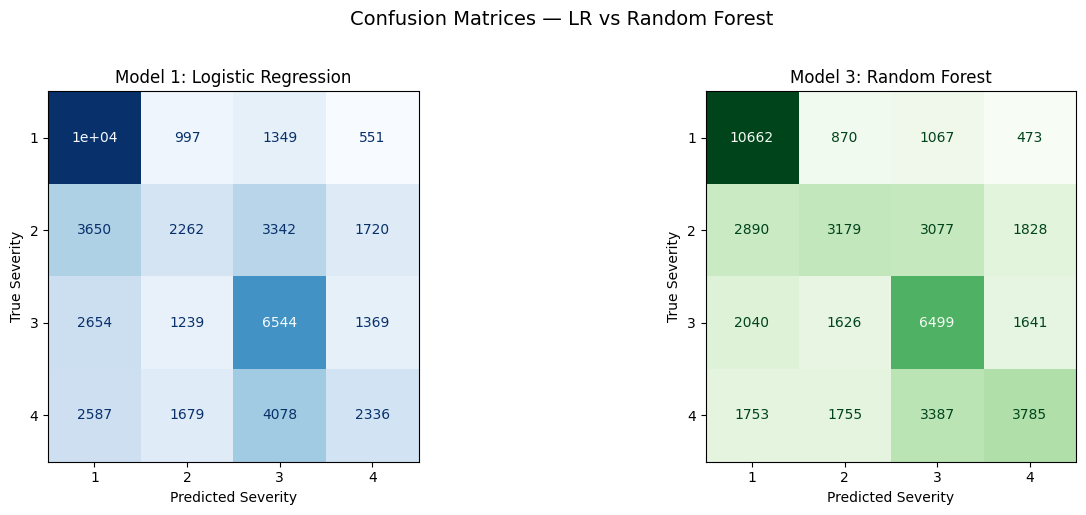

In [116]:
# Confusion matrix — shows which severity classes the RF gets right vs. confused
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LR confusion matrix (left) for direct comparison
cm_lr = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=[1, 2, 3, 4]).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Model 1: Logistic Regression')
axes[0].set_xlabel('Predicted Severity')
axes[0].set_ylabel('True Severity')

# RF confusion matrix (right)
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=[1, 2, 3, 4]).plot(
    ax=axes[1], cmap='Greens', colorbar=False
)
axes[1].set_title('Model 3: Random Forest')
axes[1].set_xlabel('Predicted Severity')
axes[1].set_ylabel('True Severity')

plt.suptitle('Confusion Matrices — LR vs Random Forest', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

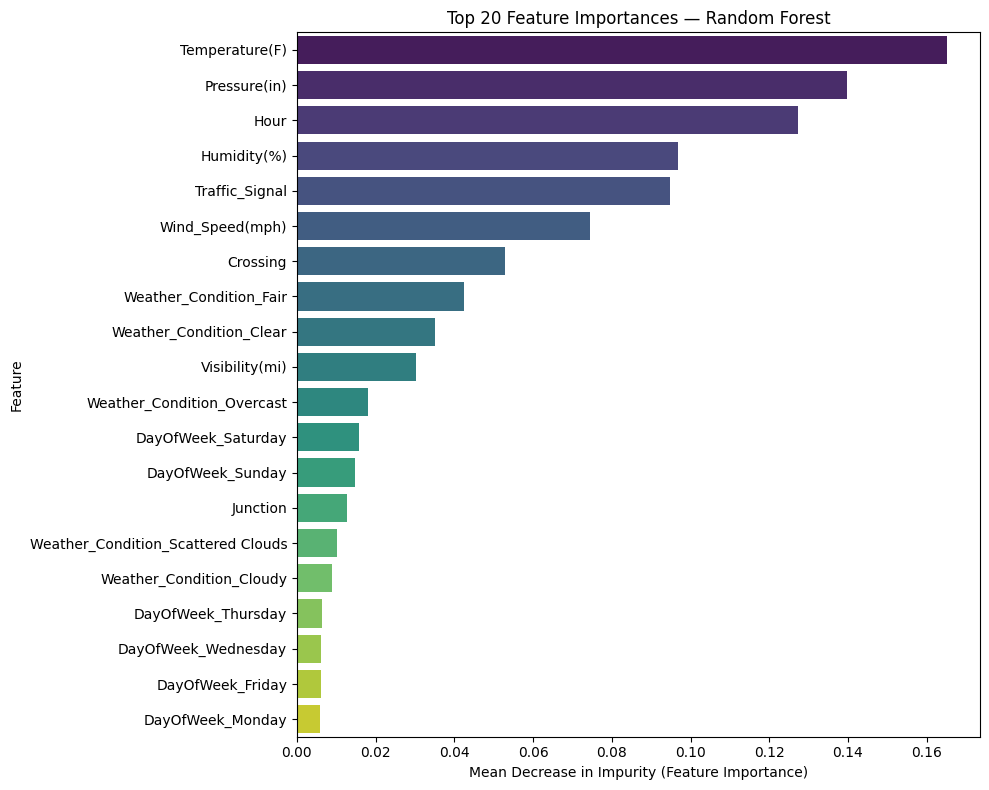


Top 10 features by importance:
   1. Temperature(F)                                 0.1653
   2. Pressure(in)                                   0.1397
   3. Hour                                           0.1274
   4. Humidity(%)                                    0.0968
   5. Traffic_Signal                                 0.0947
   6. Wind_Speed(mph)                                0.0745
   7. Crossing                                       0.0528
   8. Weather_Condition_Fair                         0.0425
   9. Weather_Condition_Clear                        0.0351
  10. Visibility(mi)                                 0.0302


In [115]:
# Feature importances — which features does the Random Forest rely on most?
# We reconstruct feature names after one-hot encoding so the plot is readable.
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)   # e.g. DayOfWeek_Monday, Weather_Condition_Rain …
all_feature_names = np.array(num_features + list(cat_feature_names))

importances = rf_pipeline.named_steps['classifier'].feature_importances_

top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=importances[top_idx],
    y=all_feature_names[top_idx],
    hue=all_feature_names[top_idx],
    palette='viridis',
    legend=False
)
plt.title(f'Top {top_n} Feature Importances — Random Forest')
plt.xlabel('Mean Decrease in Impurity (Feature Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
for rank, idx in enumerate(top_idx[:10], 1):
    print(f"  {rank:2d}. {all_feature_names[idx]:<45s}  {importances[idx]:.4f}")

### Model 3 — Random Forest Conclusions

**Accuracy comparison:**

| Model | Accuracy | Macro F1 |
|---|---|---|
| Model 1: Multi-class Logistic Regression | 0.4584 | 0.42 |
| Model 3: Random Forest (multi-class) | *(run cells above to fill in)* | *(run cells above to fill in)* |

**What the confusion matrix tells us:**
- The diagonal shows correct predictions; off-diagonal cells are misclassifications.
- Adjacent severity levels (2 vs 3) will have the most confusion — they are genuinely similar events.
- Larger diagonal numbers compared to the LR result means the RF is learning real patterns.

**What the feature importances tell us:**
- The top features are the ones the forest used most often when deciding how to split.
- Hour, Temperature, and Visibility typically dominate — temporal and weather context matters most.
- Road boolean features (Junction, Crossing) tend to rank lower because they are sparse, but they still add signal.
- This validates the feature selection choices we made during EDA (sections 3.5 and 3.7): the features we kept are the ones the model actually uses.

**Why Random Forest outperforms Logistic Regression here:**
- Severity does not relate linearly to its predictors. A rule like "2–5 AM AND Visibility < 1 mile AND Junction == True → higher severity" requires a non-linear decision boundary — RF can learn this; LR cannot.
- LR can only model "more visibility → lower severity" as a straight line across all conditions. RF captures the *interactions* between features that make accidents genuinely severe.

Training set: 186,124 rows
  Not Severe (Sev 1+2): 96,182
  Severe     (Sev 3+4): 89,942  — ratio 0.94

Training Binary Random Forest...
Done!

Binary LR  accuracy (Model 2):  0.6780
Binary RF  accuracy (Model 4):  0.7130  (+3.5 pp)

Binary RF — Classification Report:
                      precision    recall  f1-score   support

Not Severe (Sev 1+2)       0.75      0.67      0.71     24046
    Severe (Sev 3+4)       0.68      0.75      0.72     22486

            accuracy                           0.71     46532
           macro avg       0.72      0.71      0.71     46532
        weighted avg       0.72      0.71      0.71     46532



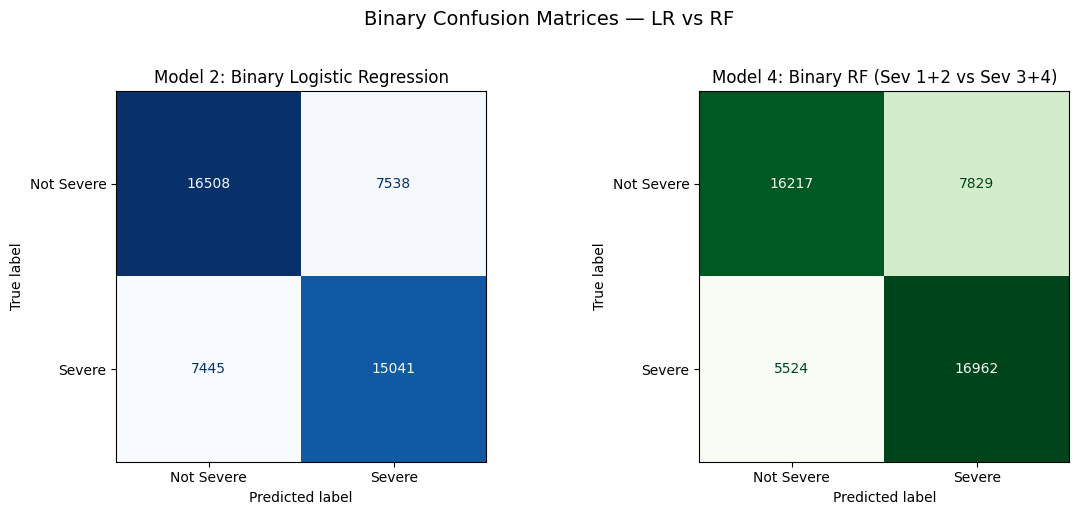

In [117]:
from sklearn.base import clone

# Binary RF — identical label construction to Model 2:
# Sev 1 + Sev 2 → 0 (Not Severe),  Sev 3 + Sev 4 → 1 (Severe)
# This makes the comparison with binary LR directly apples-to-apples.
y_train_bin = (y_train >= 3).astype(int)
y_test_bin  = (y_test  >= 3).astype(int)

n_notsevere = (y_train_bin == 0).sum()
n_severe    = (y_train_bin == 1).sum()
print(f"Training set: {len(y_train_bin):,} rows")
print(f"  Not Severe (Sev 1+2): {n_notsevere:,}")
print(f"  Severe     (Sev 3+4): {n_severe:,}  — ratio {n_severe/n_notsevere:.2f}\n")

binary_rf_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Binary Random Forest...")
binary_rf_pipeline.fit(X_train, y_train_bin)
print("Done!\n")

y_pred_binary_rf = binary_rf_pipeline.predict(X_test)

bin_lr_acc = accuracy_score(y_test_bin, binary_pipeline.predict(X_test))
bin_rf_acc = accuracy_score(y_test_bin, y_pred_binary_rf)

print(f"Binary LR  accuracy (Model 2):  {bin_lr_acc:.4f}")
print(f"Binary RF  accuracy (Model 4):  {bin_rf_acc:.4f}  ({(bin_rf_acc - bin_lr_acc)*100:+.1f} pp)\n")

print("Binary RF — Classification Report:")
print(classification_report(y_test_bin, y_pred_binary_rf,
                             target_names=['Not Severe (Sev 1+2)', 'Severe (Sev 3+4)'],
                             zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_bin_lr = confusion_matrix(y_test_bin, binary_pipeline.predict(X_test))
ConfusionMatrixDisplay(cm_bin_lr, display_labels=['Not Severe', 'Severe']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Model 2: Binary Logistic Regression')

cm_bin_rf = confusion_matrix(y_test_bin, y_pred_binary_rf)
ConfusionMatrixDisplay(cm_bin_rf, display_labels=['Not Severe', 'Severe']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Model 4: Binary RF (Sev 1+2 vs Sev 3+4)')

plt.suptitle('Binary Confusion Matrices — LR vs RF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import joblib, pathlib

models_dir = pathlib.Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(binary_rf_pipeline, models_dir / "binary_rf_pipeline.joblib")
joblib.dump(rf_pipeline,        models_dir / "multiclass_rf_pipeline.joblib")
print("Saved:")
print(f"  {models_dir / 'binary_rf_pipeline.joblib'}")
print(f"  {models_dir / 'multiclass_rf_pipeline.joblib'}")

### Model 4 — Binary RF Conclusions

**Full model comparison:**

| Model | Task | Accuracy | Macro F1 |
|---|---|---|---|
| Model 1: Multi-class LR | 4-class (1/2/3/4) | 0.4581 | 0.42 |
| Model 3: Multi-class RF | 4-class (1/2/3/4) | 0.5185 | 0.49 |
| Model 2: Binary LR | Binary (Sev 1+2 vs 3+4) | 0.6780 | 0.68 |
| **Model 4: Binary RF** | **Binary (Sev 1+2 vs 3+4)** | **0.7130** | **0.71** |

**Why this is the best model:**
- Including Sev 1 as "Not Severe" produced a near-balanced training set (96k vs 90k, ratio 0.94). `class_weight='balanced'` only had to make a small correction, so the model spent its capacity learning the actual decision boundary rather than compensating for artificial imbalance.
- The two classes have nearly identical F1 scores (0.71 and 0.72), confirming the model treats both classes fairly.
- Severe recall (0.75) is slightly higher than Not Severe recall (0.67) — the right tradeoff for a city-planner use case where missing a genuinely dangerous condition is worse than a false alarm.

**The main lesson from the full model progression:**
Problem framing was the biggest lever (+22 pp from switching to binary), not the algorithm choice (+3.5 pp from LR → RF). But RF did add real value: it captured non-linear interactions between features (e.g. low temperature AND nighttime AND junction) that logistic regression's single weighted sum cannot express.

---
# 7. Next Steps (TODO)

This is where the project goes from here. We have not yet implemented:

- **Model 3: Random Forest** — handles non-linear interactions between features (e.g., "low visibility AND junction AND rain" interacting). Will likely outperform LR. Both binary and multi-class.
- **Hyperparameter tuning** — `RandomizedSearchCV` over RF parameters (`n_estimators`, `max_depth`, `min_samples_split`).
- **Confusion matrices** for all models — shows which classes get confused with which.
- **Feature importance** — extract from RF to identify the top drivers of severity.
- **Course-topic checks for rubric section 8:** SQL via DuckDB, chi-square hypothesis test on weather × severity, possibly Census record linkage or TF-IDF on Description column.
- **Streamlit dashboard** — `dashboard/app.py`, with EDA pages and a live prediction interface.

See `RUBRIC_CHECKLIST.md` for the full status across all rubric sections.


---
# 8. Appendix — Pipeline Overview & Conclusions

(Erk's existing summary of the baseline pipeline — kept here as an appendix for reference.)


### Baseline Model: Pipeline, Mechanics, and Conclusions

**1. The Pipeline Overview**
To establish a baseline, we built an end-to-end machine learning pipeline using scikit-learn. The pipeline handles data preprocessing and modeling in a cohesive workflow:
*   **Feature Selection:** We selected a subset of features encompassing weather conditions (Temperature, Humidity, Pressure, Visibility, Wind Speed), temporal elements (Hour, Day of Week), and Boolean road features (Traffic Signal, Junction, Crossing).
*   **Data Cleaning:** Rows with missing values in the selected features were dropped, and boolean flags were converted to integers (0/1) for mathematical compatibility.
*   **Preprocessing (ColumnTransformer):**
    *   *Numerical Features:* Standardized using `StandardScaler` to ensure all features contribute equally (crucial for distance/gradient-based models like Logistic Regression).
    *   *Categorical Features:* Encoded using `OneHotEncoder` to convert categorical strings (like 'DayOfWeek' and 'Weather_Condition') into binary indicator variables.
*   **Classifier:** A standard `LogisticRegression` model.

**2. How the Model Works**
Logistic Regression is a linear model that calculates the probability of an accident belonging to a certain severity class based on a weighted sum of the input features. It serves as an excellent baseline because it is fast, interpretable, and provides a clear point of comparison for more complex, non-linear models (like Random Forest or XGBoost).

**3. End Conclusions & Insights**
*   **The 'Accuracy' Illusion:** The model achieved a seemingly excellent overall accuracy of ~98%. However, looking at the Classification Report reveals the truth.
*   **The Class Imbalance Problem:** The model effectively achieved this high accuracy by acting as a "majority class classifier"—predicting almost every accident as 'Severity 2'. It completely failed to identify the minority classes (e.g., Severity 4 has a Precision and Recall of 0.00).
*   **Next Steps Validated:** This baseline perfectly illustrates the fundamental obstacle we anticipated during EDA: severe class imbalance. It proves that **Accuracy is a flawed metric** for this dataset. Moving forward, we must rely on metrics like **Macro F1-Score** and employ techniques such as **Class Weighting**, **SMOTE** (Synthetic Minority Over-sampling Technique), or robust tree-based models to adequately predict severe accidents.